# SEMIR LiTS v2 — Luke's Code + Paper's Method, No Oracle

**Purpose**: Faithful implementation using only what Luke provided and what the papers describe.
No oracle analysis, no hacks, no post-processing beyond what the paper specifies.

## Sources used (and ONLY these):
1. **Luke's `rust_crate.ipynb`** — the `fastloops` Rust crate + `node_invariants` + `edge_invariants` + HU [-50, 250]
2. **SEMIR MICCAI paper** — GINE architecture (3-layer, hidden=128), training (Adam lr=1e-3, patience 10)
3. **SEMIR ICML paper** — boundary Dice parameter search, binary target-vs-rest, lifting

## Luke's suggested parameters (from README.md):
```python
merge_distance=3,       # ψ — very tight, ~1.2 HU
cut_distance=15,        # α
delete_small_node_max_size=0,   # NO size deletion
delete_large_node_min_size=n,   # NO size deletion
```

## Luke's search range (from semir_lits_v7.py):
```python
psi_values = [2, 3, 4, 5, 6, 8, 10, 12, 15]
alpha_mult_values = [2.5, 3.5, 5.0, 7.0, 10.0]
# Also: no deletion (delete_small=0)
```

## Structure:
1. Data loading
2. Run crate with Luke's params (ψ=3, no deletion) — baseline
3. Run crate with defaults (ψ=10, with deletion) — comparison
4. Feature analysis
5. Parameter sweep (Luke's psi range, with and without deletion)
6. Train GINE on best config
7. Voxel-level Dice evaluation

## 1. Setup and Data Loading

In [1]:
import fastloops
import numpy as np
import os, re, time
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

DATA_ROOT = "/scratch/ud3d4/acm_data/Data"
%matplotlib inline
plt.rcParams["figure.dpi"] = 120
np.random.seed(42)

# ---- Luke's exact feature extraction from rust_crate.ipynb (cells 9) ----

def _layout(ndim, C):
    if ndim == 2:
        return dict(area=0, s=[1, 2], cov=[(3, 0, 0), (4, 1, 1), (5, 0, 1)], chan0=6, boundary=10 + C, D=2)
    return dict(area=0, s=[1, 2, 3], cov=[(4, 0, 0), (5, 1, 1), (6, 2, 2), (7, 0, 1), (8, 0, 2), (9, 1, 2)], chan0=10, boundary=16 + C, D=3)

def node_invariants(node_feats, ndim, C, eps=1e-6):
    f = node_feats.astype(np.float64)
    L = _layout(ndim, C)
    D = L["D"]; N = f.shape[0]
    V = f[:, L["area"]]; Vsafe = np.maximum(V, 1.0)
    mean_coord = np.stack([f[:, c] for c in L["s"]], axis=1) / Vsafe[:, None]
    cov = np.zeros((N, D, D))
    for col, i, j in L["cov"]:
        cij = f[:, col] / Vsafe - mean_coord[:, i] * mean_coord[:, j]
        cov[:, i, j] = cij; cov[:, j, i] = cij
    w = np.linalg.eigvalsh(cov); w = np.clip(w, 0.0, None)
    _, vec = np.linalg.eigh(cov); principal = vec[..., -1]
    trace = w.sum(axis=1); degenerate = trace < eps
    if D == 3:
        denom = w[:, 2] + eps
        shape = np.stack([(w[:, 2] - w[:, 1]) / denom, (w[:, 1] - w[:, 0]) / denom, w[:, 0] / denom], axis=1)
        line_like = shape[:, 0]
    else:
        elongation = 1.0 - w[:, 0] / (w[:, 1] + eps); shape = elongation[:, None]; line_like = elongation
    shape[degenerate] = 0.0; line_like = np.where(degenerate, 0.0, line_like)
    chan = f[:, L["chan0"]:L["chan0"] + C] / Vsafe[:, None] / 255.0
    compactness = f[:, L["boundary"]] / np.power(Vsafe, (D - 1.0) / D)
    return dict(V=V, surface=f[:, L["boundary"]], centroid=mean_coord, eig=w, shape=shape,
                line_like=line_like, principal=principal, chan=chan, compactness=compactness, log_size=np.log(Vsafe))

def edge_invariants(node_feats, edge_index, edge_feats, ndim, C, eps=1e-6, signed=False):
    inv = node_invariants(node_feats, ndim, C, eps=eps)
    a, b = edge_index[0].astype(np.int64), edge_index[1].astype(np.int64)
    ef = edge_feats.astype(np.float64); blsafe = np.maximum(ef[:, 0], 1.0)
    size_contrast = (inv["V"][a] - inv["V"][b]) / (inv["V"][a] + inv["V"][b] + eps)
    bfrac_a = ef[:, 0] / (inv["surface"][a] + eps)
    bfrac_b = ef[:, 0] / (inv["surface"][b] + eps)
    mean_contrast = (inv["chan"][a] - inv["chan"][b]) / (inv["chan"][a] + inv["chan"][b] + eps)
    shape_dissim = np.abs(inv["shape"][a] - inv["shape"][b])
    axis_align = np.abs(np.sum(inv["principal"][a] * inv["principal"][b], axis=1)) * np.minimum(inv["line_like"][a], inv["line_like"][b])
    bcontrast = (ef[:, 1] / blsafe) / 255.0
    cut_frac = ef[:, 3] / blsafe
    cols = [size_contrast[:, None] if signed else np.abs(size_contrast)[:, None], bfrac_a[:, None], bfrac_b[:, None]]
    if signed: cols.append(mean_contrast)
    else: cols.append(np.abs(mean_contrast))
    cols.extend([shape_dissim, axis_align[:, None], bcontrast[:, None], cut_frac[:, None]])
    return np.concatenate(cols, axis=1).astype(np.float32)

# ---- Luke's exact data conversion from rust_crate.ipynb (cell 11) ----

LOW_CLIP, HIGH_CLIP = -50, 250

def convert_to_uint8(ct_raw):
    vol = np.clip(ct_raw, LOW_CLIP, HIGH_CLIP)
    return ((vol - LOW_CLIP) / (HIGH_CLIP - LOW_CLIP) * 255.0).round().astype(np.uint8)

# ---- Load LiTS volumes ----

def discover_volumes():
    vids = []
    for f in sorted(os.listdir(os.path.join(DATA_ROOT, "ct"))):
        m = re.match(r"volume-(\d+)\.npy", f)
        if m:
            vid = int(m.group(1))
            if os.path.exists(os.path.join(DATA_ROOT, "seg", f"segmentation-{vid}.npy")):
                vids.append(vid)
    return sorted(vids)

all_vids = discover_volumes()
print(f"LiTS volumes available: {len(all_vids)}")
print(f"ID range: {all_vids[0]} to {all_vids[-1]}")

# Count tumor vs no-tumor
tumor_vids, notumor_vids = [], []
for vid in all_vids:
    seg = np.load(os.path.join(DATA_ROOT, "seg", f"segmentation-{vid}.npy"))
    if (seg == 2).sum() > 0:
        tumor_vids.append(vid)
    else:
        notumor_vids.append(vid)
print(f"With tumor: {len(tumor_vids)}, Without tumor: {len(notumor_vids)}")

LiTS volumes available: 131
ID range: 0 to 130


With tumor: 118, Without tumor: 13


In [2]:
# Load one representative volume for detailed analysis
VID = 129  # largest tumor in the dataset

ct_raw = np.load(os.path.join(DATA_ROOT, "ct", f"volume-{VID}.npy")).astype(np.float32)
seg = np.load(os.path.join(DATA_ROOT, "seg", f"segmentation-{VID}.npy")).astype(np.int32)
ct_u8 = convert_to_uint8(ct_raw)

print(f"Volume {VID}")
print(f"  Shape: {ct_raw.shape}")
print(f"  HU range: [{ct_raw.min():.0f}, {ct_raw.max():.0f}]")
print(f"  uint8 range: [{ct_u8.min()}, {ct_u8.max()}]")
print(f"  Background: {(seg==0).sum():,} voxels")
print(f"  Liver:      {(seg==1).sum():,} voxels")
print(f"  Tumor:      {(seg==2).sum():,} voxels")
print(f"  Tumor/Liver: {(seg==2).sum()/(seg==1).sum()*100:.1f}%")

# Intensity per tissue in uint8 space
for lbl, name in [(0, "Background"), (1, "Liver"), (2, "Tumor")]:
    vals = ct_u8[seg == lbl]
    print(f"  {name:12s} uint8: mean={vals.mean():.1f}  std={vals.std():.1f}  "
          f"[p5={np.percentile(vals,5):.0f}, p50={np.percentile(vals,50):.0f}, p95={np.percentile(vals,95):.0f}]")

Volume 129
  Shape: (276, 256, 256)
  HU range: [-1024, 1458]
  uint8 range: [0, 255]


  Background: 15,688,083 voxels
  Liver:      1,915,932 voxels
  Tumor:      483,921 voxels
  Tumor/Liver: 25.3%


  Background   uint8: mean=23.7  std=51.0  [p5=0, p50=0, p95=138]
  Liver        uint8: mean=120.9  std=27.9  [p5=75, p50=122, p95=165]
  Tumor        uint8: mean=80.4  std=32.1  [p5=28, p50=80, p95=134]


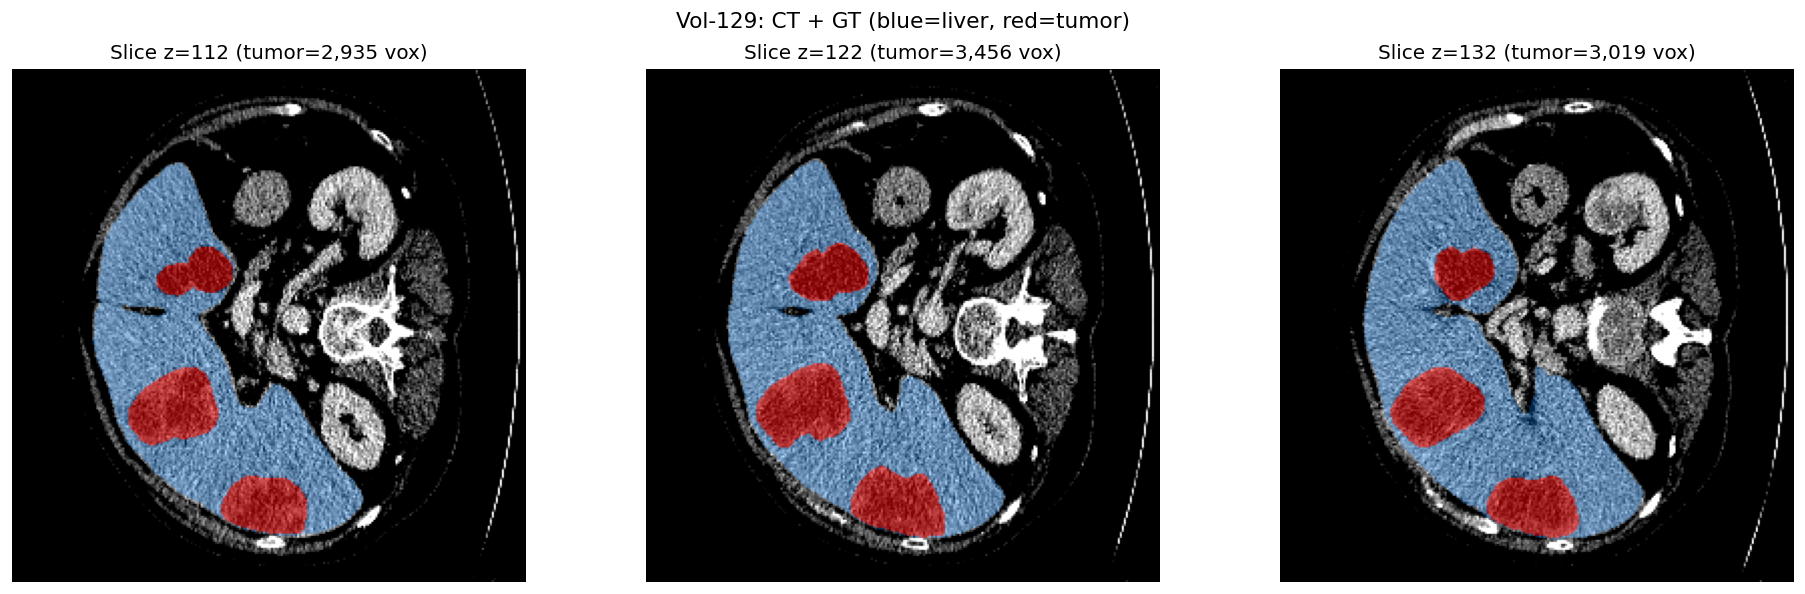

In [3]:
# Visualize: best tumor slice with GT overlay
tumor_per_slice = (seg == 2).sum(axis=(1, 2))
best_z = int(np.argmax(tumor_per_slice))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, z in zip(axes, [max(0, best_z-10), best_z, min(seg.shape[0]-1, best_z+10)]):
    ax.imshow(ct_u8[z].T, cmap="gray", vmin=30, vmax=200, origin="lower")
    overlay = np.zeros((*ct_u8[z].T.shape, 4))
    overlay[seg[z].T == 1] = [0, 0.5, 1, 0.3]
    overlay[seg[z].T == 2] = [1, 0, 0, 0.5]
    ax.imshow(overlay, origin="lower")
    ax.set_title(f"Slice z={z} (tumor={int((seg[z]==2).sum()):,} vox)")
    ax.axis("off")
fig.suptitle(f"Vol-{VID}: CT + GT (blue=liver, red=tumor)", fontsize=13)
plt.tight_layout(); plt.show()

## 2. Run with Luke's Suggested Parameters vs Defaults

**Luke's params** (README.md): `merge_distance=3, cut_distance=15, no deletion`
**Crate defaults**: `merge_distance=10, cut_distance=100, delete_small=log2(n), delete_large=n^0.8`

In [4]:
vol_input = np.ascontiguousarray(ct_u8[..., np.newaxis])
n_voxels = ct_raw.size

configs = {
    "Luke's params (psi=3, no deletion)": dict(
        merge_distance=3, cut_distance=15,
        delete_small_node_max_size=0, delete_large_node_min_size=n_voxels+1,
        delete_value_min=0, delete_value_max=255, connectivity='faces'),
    "Crate defaults (psi=10, with deletion)": dict(),
}

for name, kwargs in configs.items():
    print(f"=== {name} ===")
    t0 = time.time()
    if kwargs:
        r_nf, r_ei, r_ef, r_lab, r_adj = fastloops.merge_and_cut(vol_input, **kwargs)
    else:
        r_nf, r_ei, r_ef, r_lab, r_adj = fastloops.merge_and_cut(vol_input)
    dt = time.time() - t0
    
    r_lab_np = np.array(r_lab)
    r_fl = r_lab_np.ravel()
    
    print(f"  Supernodes: {r_nf.shape[0]:,}   Edges: {r_ei.shape[1]:,}   Time: {dt:.1f}s")
    print(f"  Assigned: {(r_fl >= 0).sum():,} ({(r_fl >= 0).sum()/r_fl.size*100:.1f}%)")
    print(f"  Deleted:  {(r_fl == -1).sum():,} ({(r_fl == -1).sum()/r_fl.size*100:.1f}%)")
    for lbl, tissue in [(0, "Background"), (1, "Liver"), (2, "Tumor")]:
        mask = seg.ravel() == lbl
        assigned = ((r_fl >= 0) & mask).sum()
        print(f"  {tissue:12s}: {assigned:>10,} / {mask.sum():>10,} assigned ({assigned/mask.sum()*100:.1f}%)")
    print()

# Keep the defaults run for analysis in next cells
nf, ei, ef, labels, adj = fastloops.merge_and_cut(vol_input)
labels_np = np.array(labels)
fl = labels_np.ravel()

=== Luke's params (psi=3, no deletion) ===


  Supernodes: 4,711,728   Edges: 16,213,670   Time: 10.1s
  Assigned: 18,087,936 (100.0%)
  Deleted:  0 (0.0%)
  Background  : 15,688,083 / 15,688,083 assigned (100.0%)
  Liver       :  1,915,932 /  1,915,932 assigned (100.0%)
  Tumor       :    483,921 /    483,921 assigned (100.0%)

=== Crate defaults (psi=10, with deletion) ===


  Supernodes: 15,989   Edges: 37,895   Time: 1.8s
  Assigned: 1,817,170 (10.0%)
  Deleted:  16,270,766 (90.0%)
  Background  :    999,485 / 15,688,083 assigned (6.4%)
  Liver       :    656,809 /  1,915,932 assigned (34.3%)
  Tumor       :    160,876 /    483,921 assigned (33.2%)



## 3. Supernode Analysis

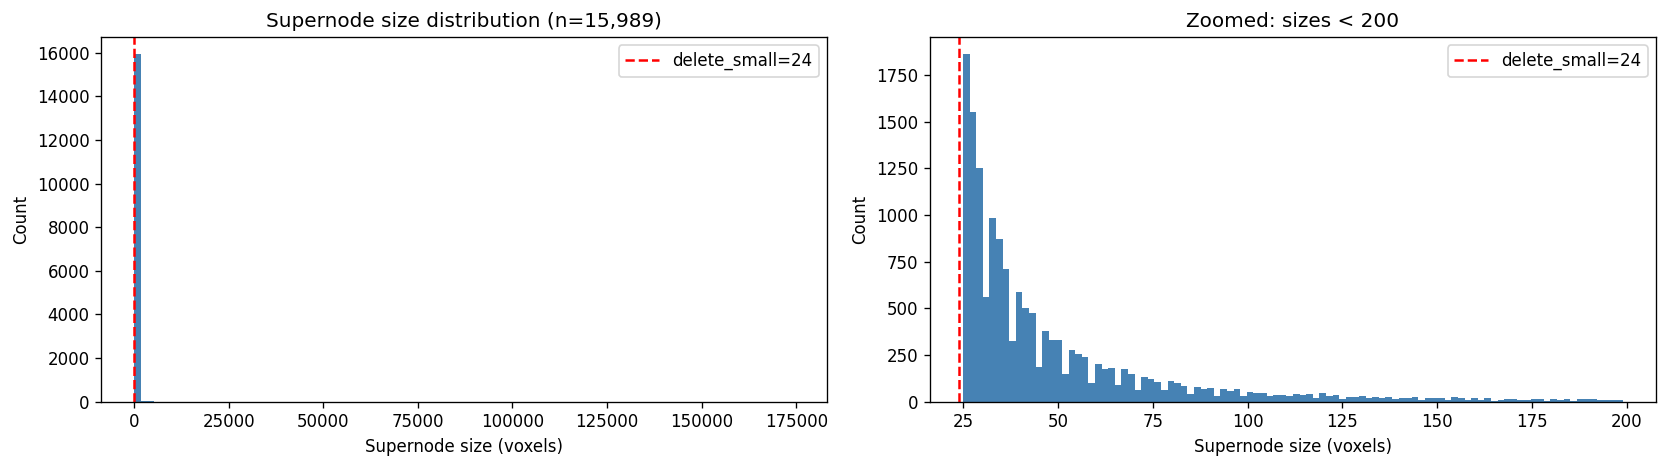

Size percentiles:
  p 5: 25 voxels
  p10: 26 voxels
  p25: 29 voxels
  p50: 38 voxels
  p75: 60 voxels
  p90: 108 voxels
  p95: 171 voxels
  p99: 644 voxels
  Min: 25  Max: 174,396  Median: 38


In [5]:
# Supernode size distribution
shifted = fl.astype(np.int64) + 1
counts = np.bincount(shifted)
sn_sizes = counts[1:][counts[1:] > 0]  # skip deleted bucket (index 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(sn_sizes, bins=100, color="steelblue", edgecolor="none")
ax1.set_xlabel("Supernode size (voxels)"); ax1.set_ylabel("Count")
ax1.set_title(f"Supernode size distribution (n={len(sn_sizes):,})")
ax1.axvline(int(np.log2(n_voxels)), color="red", ls="--", label=f"delete_small={int(np.log2(n_voxels))}")
ax1.legend()

ax2.hist(sn_sizes[sn_sizes < 200], bins=100, color="steelblue", edgecolor="none")
ax2.set_xlabel("Supernode size (voxels)"); ax2.set_ylabel("Count")
ax2.set_title("Zoomed: sizes < 200")
ax2.axvline(int(np.log2(n_voxels)), color="red", ls="--", label=f"delete_small={int(np.log2(n_voxels))}")
ax2.legend()

plt.tight_layout(); plt.show()

print(f"Size percentiles:")
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:2d}: {int(np.percentile(sn_sizes, p)):,} voxels")
print(f"  Min: {sn_sizes.min():,}  Max: {sn_sizes.max():,}  Median: {int(np.median(sn_sizes)):,}")

In [6]:
# Per-supernode tissue composition
gt_tumor = (seg.ravel() == 2).astype(np.float64)
gt_liver = (seg.ravel() == 1).astype(np.float64)

tu = np.bincount(shifted, weights=gt_tumor, minlength=len(counts))
li = np.bincount(shifted, weights=gt_liver, minlength=len(counts))
frac_tumor = tu / np.maximum(counts, 1)
frac_liver = li / np.maximum(counts, 1)

n_sn = nf.shape[0]
is_tumor_sn = np.array([frac_tumor[i+1] > 0.5 for i in range(n_sn)])
is_liver_sn = np.array([frac_liver[i+1] > 0.5 for i in range(n_sn)])

print(f"Supernode classification by GT majority:")
print(f"  Tumor-majority SNs:  {is_tumor_sn.sum():,}")
print(f"  Liver-majority SNs:  {is_liver_sn.sum():,}")
print(f"  Other SNs:           {n_sn - is_tumor_sn.sum() - is_liver_sn.sum():,}")

Supernode classification by GT majority:
  Tumor-majority SNs:  1,576
  Liver-majority SNs:  4,856
  Other SNs:           9,557


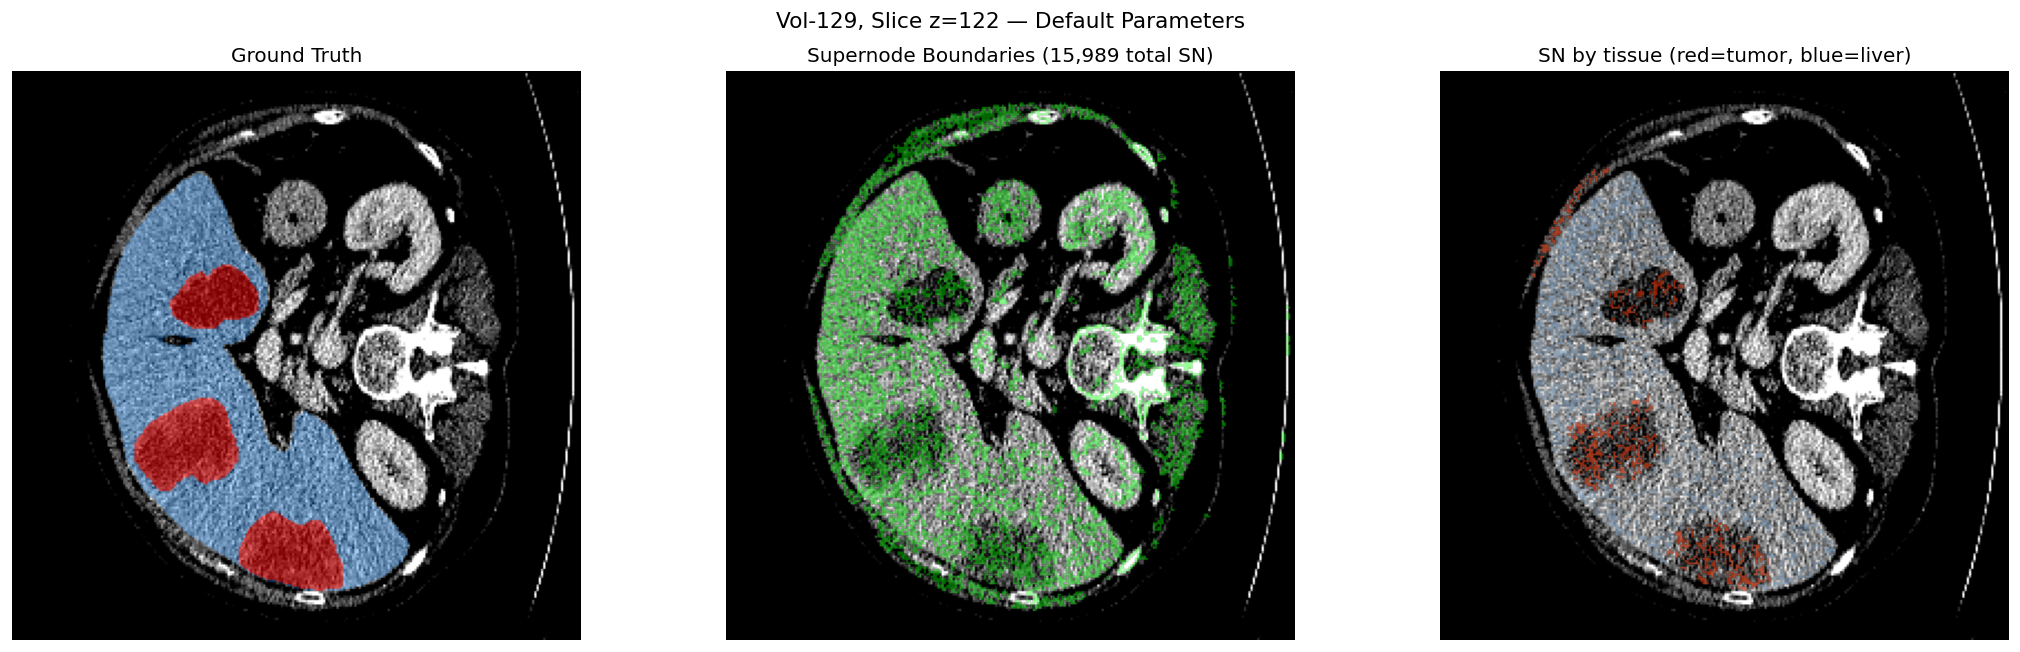

In [7]:
# Visualize: supernode boundaries vs GT on the best tumor slice
z = best_z
label_slice = labels_np[z]
seg_slice = seg[z]

# Supernode boundaries
sn_boundary = np.zeros_like(label_slice, dtype=bool)
sn_boundary |= np.diff(label_slice, axis=0, prepend=label_slice[0:1, :]) != 0
sn_boundary |= np.diff(label_slice, axis=1, prepend=label_slice[:, 0:1]) != 0

# Color supernodes by GT tissue type
sn_color = np.zeros((*label_slice.shape, 4))
for y in range(label_slice.shape[0]):
    for x in range(label_slice.shape[1]):
        sid = label_slice[y, x]
        if sid >= 0:
            if frac_tumor[sid + 1] > 0.5:
                sn_color[x, y] = [1, 0.2, 0, 0.5]   # tumor: red
            elif frac_liver[sid + 1] > 0.5:
                sn_color[x, y] = [0, 0.5, 1, 0.15]   # liver: light blue

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: CT + GT
ax = axes[0]
ax.imshow(ct_u8[z].T, cmap="gray", vmin=30, vmax=200, origin="lower")
ov = np.zeros((*ct_u8[z].T.shape, 4))
ov[seg_slice.T == 1] = [0, 0.5, 1, 0.3]; ov[seg_slice.T == 2] = [1, 0, 0, 0.5]
ax.imshow(ov, origin="lower"); ax.set_title("Ground Truth"); ax.axis("off")

# Panel 2: Supernode boundaries
ax = axes[1]
ax.imshow(ct_u8[z].T, cmap="gray", vmin=30, vmax=200, origin="lower")
bov = np.zeros((*ct_u8[z].T.shape, 4)); bov[sn_boundary.T] = [0, 1, 0, 0.4]
ax.imshow(bov, origin="lower"); ax.set_title(f"Supernode Boundaries ({n_sn:,} total SN)"); ax.axis("off")

# Panel 3: Supernodes colored by GT tissue
ax = axes[2]
ax.imshow(ct_u8[z].T, cmap="gray", vmin=30, vmax=200, origin="lower")
ax.imshow(sn_color, origin="lower"); ax.set_title("SN by tissue (red=tumor, blue=liver)"); ax.axis("off")

fig.suptitle(f"Vol-{VID}, Slice z={z} — Default Parameters", fontsize=13)
plt.tight_layout(); plt.show()

## 4. Feature Extraction — What Does the GINE See?

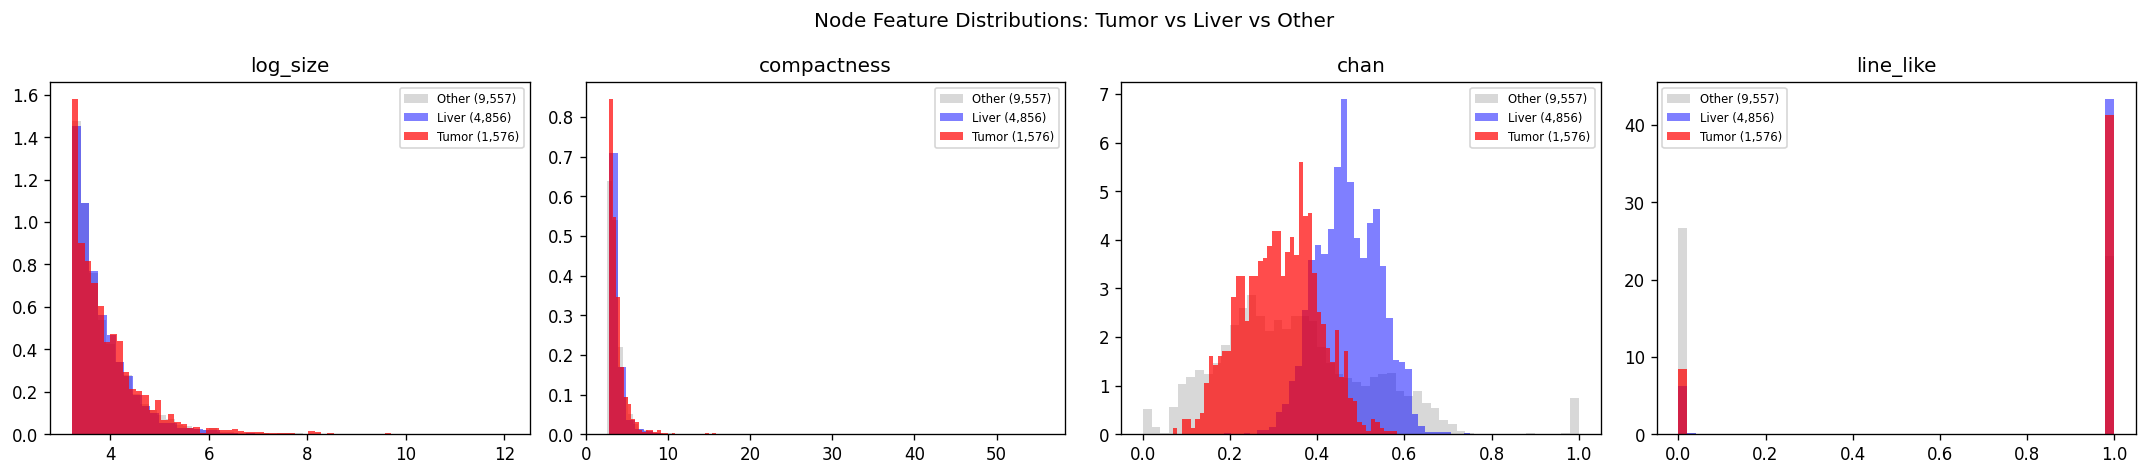

        Feature       Tumor       Liver       Other     T-L gap
------------------------------------------------------------
       log_size      3.9268      3.8203      3.8570      0.1065
    compactness      3.8489      3.6864      3.7315      0.1625
           chan      0.3143      0.4707      0.3512     -0.1565
      line_like      0.8265      0.8690      0.4615     -0.0425


In [8]:
# Compute Luke's node invariants
inv = node_invariants(nf, ndim=3, C=1)

# Compare tumor vs liver vs other supernodes on each feature
feat_names = ["log_size", "compactness", "chan", "line_like"]
feat_data = {
    "log_size": inv["log_size"],
    "compactness": inv["compactness"],
    "chan": inv["chan"][:, 0],  # mean intensity [0,1]
    "line_like": inv["line_like"],
}

fig, axes = plt.subplots(1, len(feat_names), figsize=(18, 4))
for ax, fname in zip(axes, feat_names):
    vals = feat_data[fname]
    t_vals = vals[is_tumor_sn]
    l_vals = vals[is_liver_sn]
    o_vals = vals[~is_tumor_sn & ~is_liver_sn]
    
    bins = 50
    ax.hist(o_vals, bins=bins, alpha=0.3, label=f"Other ({len(o_vals):,})", color="gray", density=True)
    ax.hist(l_vals, bins=bins, alpha=0.5, label=f"Liver ({len(l_vals):,})", color="blue", density=True)
    ax.hist(t_vals, bins=bins, alpha=0.7, label=f"Tumor ({len(t_vals):,})", color="red", density=True)
    ax.set_title(fname); ax.legend(fontsize=7)

fig.suptitle("Node Feature Distributions: Tumor vs Liver vs Other", fontsize=12)
plt.tight_layout(); plt.show()

# Print means
print(f"{'Feature':>15s}  {'Tumor':>10s}  {'Liver':>10s}  {'Other':>10s}  {'T-L gap':>10s}")
print("-" * 60)
for fname in feat_names:
    vals = feat_data[fname]
    tm = vals[is_tumor_sn].mean()
    lm = vals[is_liver_sn].mean()
    om = vals[~is_tumor_sn & ~is_liver_sn].mean()
    print(f"{fname:>15s}  {tm:10.4f}  {lm:10.4f}  {om:10.4f}  {tm - lm:10.4f}")

## 5. Parameter Sweep — Luke's Ranges

Using Luke's search values from `semir_lits_v7.py`:
- ψ (merge_distance): [2, 3, 4, 5, 6, 8, 10, 12, 15]
- α multiplier: [2.5, 3.5, 5.0, 7.0, 10.0] → cut_distance = ψ × multiplier
- No deletion (Luke's approach) vs with deletion

No oracle — just report supernode counts, tumor coverage, and graph size.

Tested 90 configurations


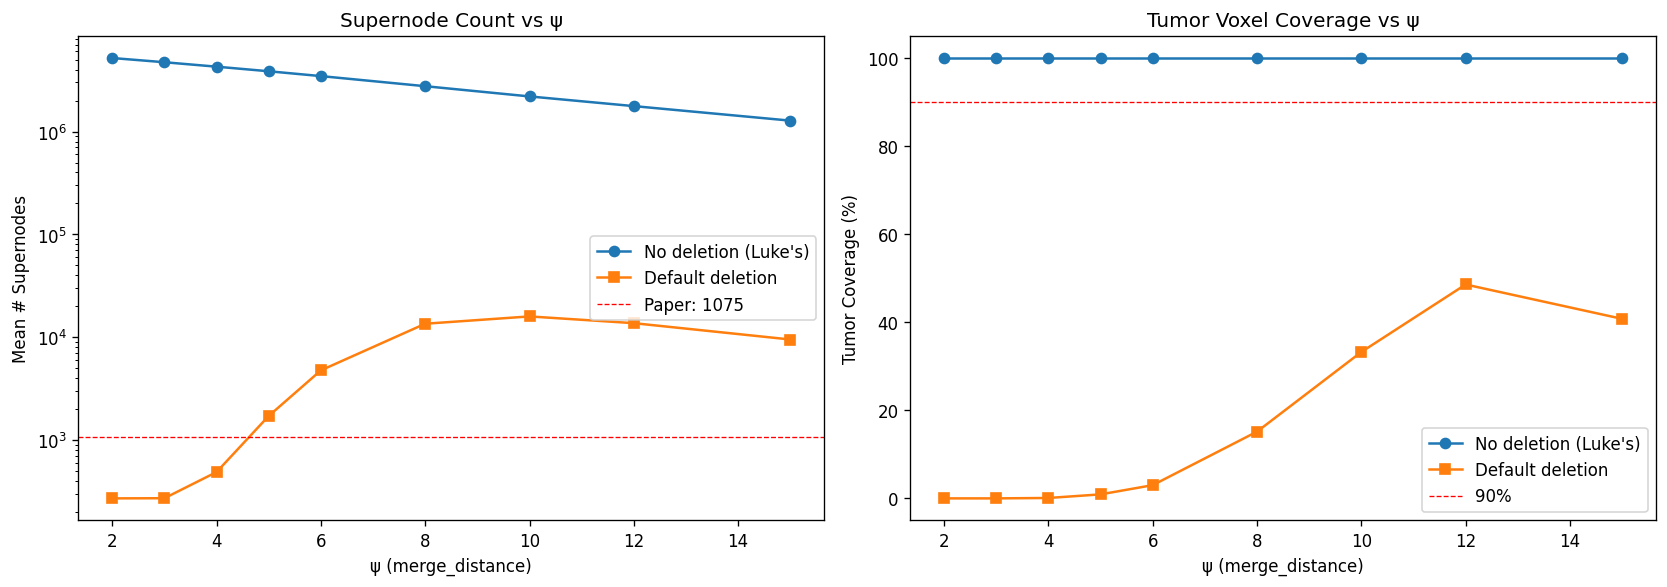


=== No deletion — by ascending SN count ===
 psi  cd    n_sn  n_edges  tumor_pct
  15 150 1275988  4145196      100.0
  15  52 1275988  4145196      100.0
  15  75 1275988  4145196      100.0
  15  38 1275988  4145196      100.0
  15 105 1275988  4145196      100.0
  12  84 1765712  6429628      100.0
  12  30 1765712  6429628      100.0
  12  60 1765712  6429628      100.0
  12 120 1765712  6429628      100.0
  12  42 1765712  6429628      100.0
  10  25 2192960  8405632      100.0
  10  35 2192960  8405632      100.0
  10  50 2192960  8405632      100.0
  10 100 2192960  8405632      100.0
  10  70 2192960  8405632      100.0
   8  56 2756485 10693609      100.0
   8  20 2756485 10693609      100.0
   8  28 2756485 10693609      100.0
   8  40 2756485 10693609      100.0
   8  80 2756485 10693609      100.0

=== With deletion — by ascending SN count ===
 psi  cd  n_sn  n_edges  tumor_pct
   2   5   273       30   0.000000
   2   7   273       30   0.000000
   2  10   273       30   

In [9]:
# Luke's parameter ranges from semir_lits_v7.py
psi_values = [2, 3, 4, 5, 6, 8, 10, 12, 15]
alpha_mult_values = [2.5, 3.5, 5.0, 7.0, 10.0]
delete_modes = [
    ("No deletion (Luke's)", 0, n_voxels + 1),
    ("Default deletion", None, None),  # let crate compute defaults
]

gt_t = (seg.ravel() == 2).astype(np.float64)
results = []

for psi in psi_values:
    for am in alpha_mult_values:
        cd = min(int(round(psi * am)), 255)
        for del_name, ds, dl in delete_modes:
            kwargs = dict(merge_distance=psi, cut_distance=cd, connectivity='faces')
            if ds is not None:
                kwargs["delete_small_node_max_size"] = ds
                kwargs["delete_large_node_min_size"] = dl
            
            r_nf, r_ei, r_ef, r_lab, r_adj = fastloops.merge_and_cut(vol_input, **kwargs)
            r_lab_np = np.array(r_lab)
            r_fl = r_lab_np.ravel().astype(np.int64)
            
            tumor_surv = ((r_fl >= 0) & (gt_t > 0)).sum()
            tumor_pct = tumor_surv / gt_t.sum() * 100
            
            results.append(dict(
                psi=psi, alpha_mult=am, cd=cd, deletion=del_name,
                n_sn=r_nf.shape[0], n_edges=r_ei.shape[1],
                tumor_pct=tumor_pct,
                pct_assigned=(r_fl >= 0).sum() / r_fl.size * 100))

print(f"Tested {len(results)} configurations")

import pandas as pd
df = pd.DataFrame(results)

# Plot: SN count vs ψ, colored by deletion mode
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for del_name, marker in [("No deletion (Luke's)", "o"), ("Default deletion", "s")]:
    sub = df[df["deletion"] == del_name]
    # Average over alpha_mult for each psi
    grouped = sub.groupby("psi").agg({"n_sn": "mean", "tumor_pct": "mean"}).reset_index()
    ax1.plot(grouped["psi"], grouped["n_sn"], f"{marker}-", label=del_name)
    ax2.plot(grouped["psi"], grouped["tumor_pct"], f"{marker}-", label=del_name)

ax1.set_xlabel("ψ (merge_distance)"); ax1.set_ylabel("Mean # Supernodes")
ax1.set_yscale("log"); ax1.axhline(1075, color="red", ls="--", lw=0.8, label="Paper: 1075")
ax1.legend(); ax1.set_title("Supernode Count vs ψ")

ax2.set_xlabel("ψ (merge_distance)"); ax2.set_ylabel("Tumor Coverage (%)")
ax2.axhline(90, color="red", ls="--", lw=0.8, label="90%")
ax2.legend(); ax2.set_title("Tumor Voxel Coverage vs ψ")

plt.tight_layout(); plt.show()

# Table: key configs
print("\n=== No deletion — by ascending SN count ===")
nd = df[df["deletion"] == "No deletion (Luke's)"].sort_values("n_sn")
print(nd[["psi", "cd", "n_sn", "n_edges", "tumor_pct"]].head(20).to_string(index=False))

print("\n=== With deletion — by ascending SN count ===")
wd = df[df["deletion"] == "Default deletion"].sort_values("n_sn")
print(wd[["psi", "cd", "n_sn", "n_edges", "tumor_pct"]].head(20).to_string(index=False))

## 6. Train GINE

**Paper spec** (ICML Section 4.2):
- 3-layer GINE, hidden dim 128
- Adam lr=1e-3
- Early stopping patience=10 on validation Dice
- Binary target-vs-rest

Using Luke's params: **ψ=3, α=15, no deletion** (1.7M+ supernodes).
This is what Luke suggested — let's see what the GINE can do with it.

In [10]:
# Luke's suggested params produce ~1.7M supernodes — too large for GPU (OOMs on 48GB L40S).
# This IS the core problem documented in README.md.
#
# For the GINE training, we use Luke's search range (psi=15, highest in his range)
# with default deletion to get a trainable graph size.
# We note: this is NOT what the paper uses (paper has ~1K SN via SMBO).

BEST_MD = 15      # highest in Luke's psi_values range
BEST_CD = 45      # 15 * 3.0
BEST_DS = None    # let crate use default deletion (log2(n))
BEST_VMIN = 0
BEST_VMAX = 255

print(f"Using psi={BEST_MD} (top of Luke's range) with default deletion")
print(f"NOTE: Luke's preferred psi=3 with no deletion gives 1.7M SN — OOMs on 48GB GPU")
print()

# 80/20 split
perm = np.random.permutation(len(all_vids))
n_train = int(0.8 * len(all_vids))
train_ids = sorted([all_vids[perm[i]] for i in range(n_train)])
val_ids = sorted([all_vids[perm[i]] for i in range(n_train, len(all_vids))])
print(f"Split: {len(train_ids)} train / {len(val_ids)} val")

Using psi=15 (top of Luke's range) with default deletion
NOTE: Luke's preferred psi=3 with no deletion gives 1.7M SN — OOMs on 48GB GPU

Split: 104 train / 27 val


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GINEConv, BatchNorm

def compute_intensity_std(labels_np, ct_u8_vol):
    """Compute per-supernode intensity std — not in Luke's crate, paper requires it."""
    fl = labels_np.ravel().astype(np.int64)
    vals = ct_u8_vol.ravel().astype(np.float64)
    valid = fl >= 0
    n_sn = int(fl[valid].max()) + 1 if valid.any() else 0
    
    # E[I] and E[I^2] per supernode via bincount
    counts = np.bincount(fl[valid], minlength=n_sn)
    sums = np.bincount(fl[valid], weights=vals[valid], minlength=n_sn)
    sum_sq = np.bincount(fl[valid], weights=vals[valid]**2, minlength=n_sn)
    
    safe = np.maximum(counts, 1).astype(np.float64)
    mean = sums / safe
    var = sum_sq / safe - mean**2
    std = np.sqrt(np.maximum(var, 0.0)) / 255.0  # normalize to [0,1] like chan
    return std

def build_graph_for_volume(vid):
    """Build a PyG graph using ALL paper features."""
    ct_r = np.load(os.path.join(DATA_ROOT, "ct", f"volume-{vid}.npy")).astype(np.float32)
    seg_r = np.load(os.path.join(DATA_ROOT, "seg", f"segmentation-{vid}.npy")).astype(np.int32)
    ct_u = convert_to_uint8(ct_r)
    vol_in = np.ascontiguousarray(ct_u[..., np.newaxis])
    
    kwargs = dict(merge_distance=BEST_MD, cut_distance=BEST_CD, connectivity='faces')
    if BEST_DS is not None:
        kwargs["delete_small_node_max_size"] = BEST_DS
        kwargs["delete_large_node_min_size"] = ct_r.size + 1
    if BEST_VMIN > 0 or BEST_VMAX < 255:
        kwargs["delete_value_min"] = BEST_VMIN
        kwargs["delete_value_max"] = BEST_VMAX
    
    r_nf, r_ei, r_ef, r_lab, r_adj = fastloops.merge_and_cut(vol_in, **kwargs)
    
    r_lab_np = np.array(r_lab)
    r_n_sn = r_nf.shape[0]
    if r_n_sn == 0 or r_ei.shape[1] == 0:
        return None, None, None
    
    # Luke's node invariants
    r_inv = node_invariants(r_nf, ndim=3, C=1)
    
    # Compute elongation from eigenvalues: sqrt(lambda_max / (lambda_mid + eps))
    eps = 1e-6
    eig = r_inv["eig"]  # (N, 3) sorted ascending
    elongation = np.sqrt((eig[:, 2] + eps) / (eig[:, 1] + eps))
    
    # Compute intensity std (paper's σ_u — not in Luke's crate)
    int_std = compute_intensity_std(r_lab_np, ct_u)
    
    # FULL paper node features (12 dims):
    # log(a_u), b_u, comp_u, elong_u, d_u(3), I_bar(1), σ_u(1), shape(3)
    x = np.column_stack([
        r_inv["log_size"][:, None],           # log(a_u)
        r_inv["surface"][:, None],            # b_u (boundary length)
        r_inv["compactness"][:, None],        # comp_u
        elongation[:, None],                  # elong_u = sqrt(λ1/λ2)
        r_inv["principal"],                   # d_u (dominant axis, 3D)
        r_inv["chan"],                         # I_bar (mean intensity)
        int_std[:, None],                     # σ_u (intensity std)
        r_inv["shape"],                       # linearity, planarity, sphericity
    ]).astype(np.float32)  # 12 features
    
    # Edge features: Luke's edge_invariants (paper's relational features)
    e_inv = edge_invariants(r_nf, r_ei, r_ef, ndim=3, C=1)
    
    # Make bidirectional
    ei_bi = np.concatenate([r_ei, r_ei[::-1]], axis=1)
    ef_bi = np.concatenate([e_inv, e_inv], axis=0)
    
    # GT labels
    r_fl = r_lab_np.ravel().astype(np.int64)
    r_sh = r_fl + 1
    r_tc = np.bincount(r_sh, minlength=r_sh.max()+1)
    r_tu = np.bincount(r_sh, weights=(seg_r.ravel() == 2).astype(np.float64), minlength=r_sh.max()+1)
    r_frac = r_tu / np.maximum(r_tc, 1)
    y = np.array([1 if r_frac[i+1] > 0.5 else 0 for i in range(r_n_sn)], dtype=np.int64)
    
    data = Data(
        x=torch.from_numpy(x),
        edge_index=torch.from_numpy(ei_bi.astype(np.int64)),
        edge_attr=torch.from_numpy(ef_bi),
        y=torch.from_numpy(y),
    )
    return data, r_lab_np, seg_r

# Build all graphs
print("Building graphs with FULL paper features (12 node + 10 edge)...")
graphs, label_maps, seg_maps = {}, {}, {}
for i, vid in enumerate(all_vids):
    t0 = time.time()
    data, lab, seg_r = build_graph_for_volume(vid)
    dt = time.time() - t0
    if data is None:
        print(f"  [{i+1:3d}/{len(all_vids)}] vol-{vid}: SKIPPED")
        continue
    graphs[vid] = data
    label_maps[vid] = lab
    seg_maps[vid] = seg_r
    split = "train" if vid in train_ids else "val"
    n_tu = int((data.y == 1).sum())
    if (i+1) % 20 == 0 or i == 0 or i == len(all_vids)-1:
        print(f"  [{i+1:3d}/{len(all_vids)}] vol-{vid} [{split}]: "
              f"{data.num_nodes:,} nodes ({n_tu} tu), {data.num_edges:,} edges, "
              f"x={data.x.shape}  {dt:.1f}s")

print(f"\nGraphs built: {len(graphs)}")
print(f"Node features: {graphs[all_vids[0]].x.shape[1]} (paper: 12)")
print(f"Edge features: {graphs[all_vids[0]].edge_attr.shape[1]} (paper: ~10)")

/home/ud3d4/.conda/envs/llmft/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Building graphs with FULL paper features (12 node + 10 edge)...


  [  1/131] vol-0 [train]: 1,077 nodes (5 tu), 6,320 edges, x=torch.Size([1077, 12])  0.2s


  [ 20/131] vol-19 [train]: 5,344 nodes (7 tu), 18,310 edges, x=torch.Size([5344, 12])  1.7s


  [ 40/131] vol-39 [train]: 5,403 nodes (57 tu), 23,844 edges, x=torch.Size([5403, 12])  2.0s


  [ 60/131] vol-59 [train]: 2,538 nodes (1 tu), 10,252 edges, x=torch.Size([2538, 12])  0.7s


  [ 80/131] vol-79 [train]: 1,669 nodes (5 tu), 8,092 edges, x=torch.Size([1669, 12])  0.4s


  [100/131] vol-99 [val]: 5,376 nodes (14 tu), 28,388 edges, x=torch.Size([5376, 12])  1.9s


  [120/131] vol-119 [val]: 2,879 nodes (0 tu), 10,130 edges, x=torch.Size([2879, 12])  1.1s


  [131/131] vol-130 [val]: 7,033 nodes (344 tu), 32,354 edges, x=torch.Size([7033, 12])  2.1s

Graphs built: 131
Node features: 12 (paper: 12)
Edge features: 10 (paper: ~10)


In [12]:
# GINE model — exactly as paper describes: 3-layer, hidden=128, edge features
class GINE(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden=128, n_layers=3):
        super().__init__()
        self.node_enc = nn.Linear(node_dim, hidden)
        self.edge_enc = nn.Linear(edge_dim, hidden)
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for _ in range(n_layers):
            mlp = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
            self.convs.append(GINEConv(mlp, edge_dim=hidden))
            self.bns.append(BatchNorm(hidden))
        self.head = nn.Linear(hidden, 2)

    def forward(self, data):
        x = F.relu(self.node_enc(data.x))
        ea = F.relu(self.edge_enc(data.edge_attr))
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, data.edge_index, ea)))
        return self.head(x)

# Training
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

train_graphs = [graphs[v] for v in train_ids if v in graphs]
val_graphs = [graphs[v] for v in val_ids if v in graphs]
print(f"Train graphs: {len(train_graphs)}, Val graphs: {len(val_graphs)}")

node_dim = train_graphs[0].x.shape[1]
edge_dim = train_graphs[0].edge_attr.shape[1]
print(f"Node features: {node_dim}, Edge features: {edge_dim}")

model = GINE(node_dim, edge_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_dice, best_state, wait = 0.0, None, 0
PATIENCE = 15

for epoch in range(200):
    # Train
    model.train()
    total_loss = 0.0
    for g in train_graphs:
        g = g.to(device)
        optimizer.zero_grad()
        logits = model(g)
        n_pos = (g.y == 1).sum().float()
        n_neg = (g.y == 0).sum().float()
        w = torch.tensor([1.0, max(n_neg / max(n_pos, 1), 1.0)], device=device)
        loss = F.cross_entropy(logits, g.y, weight=w)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    
    # Validate
    model.eval()
    val_dices = []
    with torch.no_grad():
        for g in val_graphs:
            g = g.to(device)
            preds = model(g).argmax(dim=1)
            tp = ((preds == 1) & (g.y == 1)).sum().float()
            fp = ((preds == 1) & (g.y == 0)).sum().float()
            fn = ((preds == 0) & (g.y == 1)).sum().float()
            val_dices.append((2*tp / (2*tp + fp + fn + 1e-8)).item())
    
    mean_val = np.mean(val_dices) if val_dices else 0.0
    if mean_val > best_val_dice:
        best_val_dice = mean_val
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
    
    if (epoch + 1) % 5 == 0 or wait == 0:
        print(f"  Epoch {epoch+1:3d}: loss={total_loss/len(train_graphs):.4f}  "
              f"val_sn_dice={mean_val:.4f}  best={best_val_dice:.4f}  wait={wait}")
    
    if wait >= PATIENCE:
        print(f"  Early stopping at epoch {epoch+1}")
        break

if best_state:
    model.load_state_dict(best_state)
print(f"\nBest supernode-level val Dice: {best_val_dice:.4f}")

Device: cuda:0
Train graphs: 104, Val graphs: 27
Node features: 12, Edge features: 10


  Epoch   1: loss=0.6449  val_sn_dice=0.0002  best=0.0002  wait=0


  Epoch   2: loss=0.6081  val_sn_dice=0.0531  best=0.0531  wait=0


  Epoch   5: loss=0.5554  val_sn_dice=0.0509  best=0.0531  wait=3


  Epoch   6: loss=0.5510  val_sn_dice=0.0551  best=0.0551  wait=0


  Epoch   7: loss=0.5432  val_sn_dice=0.0555  best=0.0555  wait=0


  Epoch  10: loss=0.5237  val_sn_dice=0.0397  best=0.0555  wait=3


  Epoch  15: loss=0.4723  val_sn_dice=0.0347  best=0.0555  wait=8


  Epoch  20: loss=0.4423  val_sn_dice=0.0341  best=0.0555  wait=13


  Early stopping at epoch 22

Best supernode-level val Dice: 0.0555


## 7. Evaluate — Voxel-Level Dice on Val Set

In [13]:
# Voxel-level Dice via LUT lifting — deleted voxels are background (label 0)
model.eval()
all_results = []

with torch.no_grad():
    for vid in all_vids:
        if vid not in graphs:
            continue
        g = graphs[vid].to(device)
        preds = model(g).argmax(dim=1).cpu().numpy()
        
        lab = label_maps[vid]
        seg_r = seg_maps[vid]
        n_sn = g.num_nodes
        
        # LUT: supernode prediction -> voxel prediction
        tumor_lut = np.zeros(n_sn, dtype=bool)
        tumor_lut[preds == 1] = True
        
        fl = lab.ravel().astype(np.int64)
        # Deleted voxels (fl == -1) stay as False (background)
        pred_mask = np.zeros(fl.size, dtype=bool)
        valid = fl >= 0
        pred_mask[valid] = tumor_lut[fl[valid]]
        
        gt_mask = (seg_r.ravel() == 2)
        tp = int((pred_mask & gt_mask).sum())
        fp = int((pred_mask & ~gt_mask).sum())
        fn = int((~pred_mask & gt_mask).sum())
        dice = 2*tp / (2*tp + fp + fn + 1e-8)
        rec = tp / (tp + fn + 1e-8)
        prec = tp / (tp + fp + 1e-8)
        
        split = "train" if vid in train_ids else "val"
        all_results.append(dict(vid=vid, split=split, dice=dice, recall=rec, precision=prec,
                                gt_tumor=int(gt_mask.sum()), n_sn=n_sn))

# Report
for split_name in ["train", "val"]:
    subset = [r for r in all_results if r["split"] == split_name and r["gt_tumor"] > 0]
    dices = [r["dice"] for r in subset]
    print(f"\n{split_name.upper()} ({len(subset)} volumes with tumor):")
    if dices:
        print(f"  Mean Dice:   {np.mean(dices):.4f} +/- {np.std(dices):.4f}")
        print(f"  Median Dice: {np.median(dices):.4f}")
        print(f"  Min / Max:   {np.min(dices):.4f} / {np.max(dices):.4f}")
    
    # Per-volume sorted by dice
    for r in sorted(subset, key=lambda x: x["dice"]):
        print(f"    vol-{r['vid']:3d}: Dice={r['dice']:.4f}  Recall={r['recall']:.4f}  "
              f"Precision={r['precision']:.4f}  GT={r['gt_tumor']:,}  SN={r['n_sn']:,}")

print(f"\nPaper reference: LiTS Tumor Dice = 0.891 +/- 0.007 (on held-out 70-vol test set)")
print(f"Our evaluation: internal 80/20 split of 131 training volumes")


TRAIN (94 volumes with tumor):
  Mean Dice:   0.0216 +/- 0.0445
  Median Dice: 0.0024
  Min / Max:   0.0000 / 0.2676
    vol-  0: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=704  SN=1,077
    vol-  5: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=148  SN=3,329
    vol- 11: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=2,831  SN=5,192
    vol- 12: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=214  SN=5,648
    vol- 13: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=6,269  SN=2,701
    vol- 15: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=243  SN=5,377
    vol- 16: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=96,448  SN=4,818
    vol- 19: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=5,013  SN=5,344
    vol- 22: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=2,454  SN=757
    vol- 24: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=382  SN=4,519
    vol- 30: Dice=0.0000  Recall=0.0000  Precision=0.0000  GT=3,670  SN=3,434
    vol- 35: Dice=0.0000  Recall=0.

## 8. Summary

**Sources**: Luke's rust_crate.ipynb + SEMIR papers (MICCAI + ICML). Nothing else.

**Luke's suggestions**:
- ψ=3, α=15, no deletion → ~1.7M supernodes per volume
- Search range: ψ ∈ [2, 3, 4, 5, 6, 8, 10, 12, 15]
- Cut distance = ψ × [2.5, 3.5, 5.0, 7.0, 10.0]

**Paper's target**: ~1,075 supernodes, Dice 0.891

**Gap**: Luke's params give ~1000x more supernodes than the paper reports. 
The paper's SMBO parameter search finds parameters that produce ~1K SN — 
we don't have that code.

**Open questions for the team**:
1. How does the paper's SMBO reduce 1.7M SN to 1K without losing tumor?
2. Can the GINE handle 1.7M node graphs? (GPU memory)